**Best Model selectionand shap 17/2/2025**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.layers import LSTM, GRU, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Result'] = df['Result'].replace(-1, 0)

X = df.drop('Result', axis=1)
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for sequence models
X_train_seq = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_seq = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

input_dim = X_train.shape[1]
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# ======================================
# DEFINE MODELS WITH NAMES
# ======================================

models = []

# 1️⃣ Simple DNN
model1 = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(1, activation='sigmoid')
])
models.append(("Simple DNN", model1))

# 2️⃣ Deep DNN
model2 = Sequential([
    Dense(256, activation='relu', input_shape=(input_dim,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
models.append(("Deep DNN", model2))

# 3️⃣ DNN + Batch Normalization
model3 = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
models.append(("DNN + BatchNorm", model3))

# 4️⃣ DNN + Dropout
model4 = Sequential([
    Dense(256, activation='relu', input_shape=(input_dim,)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
models.append(("DNN + Dropout", model4))

# 5️⃣ 1D CNN
model5 = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(input_dim,1)),
    MaxPooling1D(2),
    Flatten(),
    Dense(1, activation='sigmoid')
])
models.append(("1D CNN", model5))

# 6️⃣ Deep 1D CNN
model6 = Sequential([
    Conv1D(128, 3, activation='relu', input_shape=(input_dim,1)),
    MaxPooling1D(2),
    Conv1D(64, 3, activation='relu'),
    Flatten(),
    Dense(1, activation='sigmoid')
])
models.append(("Deep 1D CNN", model6))

# 7️⃣ LSTM
model7 = Sequential([
    LSTM(64, input_shape=(input_dim,1)),
    Dense(1, activation='sigmoid')
])
models.append(("LSTM", model7))

# 8️⃣ GRU
model8 = Sequential([
    GRU(64, input_shape=(input_dim,1)),
    Dense(1, activation='sigmoid')
])
models.append(("GRU", model8))

# 9️⃣ Bidirectional LSTM
model9 = Sequential([
    Bidirectional(LSTM(64), input_shape=(input_dim,1)),
    Dense(1, activation='sigmoid')
])
models.append(("Bidirectional LSTM", model9))

# 🔟 CNN + LSTM Hybrid
model10 = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(input_dim,1)),
    MaxPooling1D(2),
    LSTM(64),
    Dense(1, activation='sigmoid')
])
models.append(("CNN + LSTM Hybrid", model10))

# ======================================
# TRAIN & COMPARE
# ======================================

accuracies = []

for name, model in models:
    print(f"\nTraining Model: {name}")

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    if "DNN" in name:
        model.fit(X_train, y_train,
                  epochs=30, batch_size=32,
                  validation_split=0.2,
                  callbacks=[early_stop],
                  verbose=0)
        loss, acc = model.evaluate(X_test, y_test, verbose=0)
    else:
        model.fit(X_train_seq, y_train,
                  epochs=30, batch_size=32,
                  validation_split=0.2,
                  callbacks=[early_stop],
                  verbose=0)
        loss, acc = model.evaluate(X_test_seq, y_test, verbose=0)

    print(f"{name} Accuracy: {acc}")
    accuracies.append((name, acc))

# ======================================
# FIND BEST MODEL
# ======================================

best_model = max(accuracies, key=lambda x: x[1])

print("\n==============================")
print("Best Model:", best_model[0])
print("Best Accuracy:", best_model[1])
print("==============================")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-package


Training Model: Simple DNN
Simple DNN Accuracy: 0.9642695784568787

Training Model: Deep DNN
Deep DNN Accuracy: 0.9624603986740112

Training Model: DNN + BatchNorm
DNN + BatchNorm Accuracy: 0.9669832587242126

Training Model: DNN + Dropout
DNN + Dropout Accuracy: 0.9583898782730103

Training Model: 1D CNN
1D CNN Accuracy: 0.9434645175933838

Training Model: Deep 1D CNN
Deep 1D CNN Accuracy: 0.9529624581336975

Training Model: LSTM
LSTM Accuracy: 0.9063771963119507

Training Model: GRU
GRU Accuracy: 0.9371325373649597

Training Model: Bidirectional LSTM
Bidirectional LSTM Accuracy: 0.9226594567298889

Training Model: CNN + LSTM Hybrid
CNN + LSTM Hybrid Accuracy: 0.9552238583564758

Best Model: DNN + BatchNorm
Best Accuracy: 0.9669832587242126


**DNN + BatchNorm Deep Learning Model**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Result'] = df['Result'].replace(-1, 0)

X = df.drop('Result', axis=1)
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

input_dim = X_train.shape[1]

early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

DNN_model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

DNN_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

DNN_Train = DNN_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ======================================
# EVALUATE MODEL
# ======================================
loss, accuracy = DNN_model.evaluate(X_test, y_test)

print("\n=======================")
print("DNN + BatchNorm Accuracy:", accuracy)
print("=======================")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8642 - loss: 0.3002 - val_accuracy: 0.9395 - val_loss: 0.1694
Epoch 2/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9316 - loss: 0.1600 - val_accuracy: 0.9457 - val_loss: 0.1335
Epoch 3/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9466 - loss: 0.1269 - val_accuracy: 0.9491 - val_loss: 0.1219
Epoch 4/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9501 - loss: 0.1157 - val_accuracy: 0.9576 - val_loss: 0.1143
Epoch 5/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9590 - loss: 0.0997 - val_accuracy: 0.9621 - val_loss: 0.0979
Epoch 6/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9601 - loss: 0.0991 - val_accuracy: 0.9616 - val_loss: 0.0984
Epoch 7/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9595 - loss: 0.0960 - val_accuracy: 0.9565 - val_loss: 0.1019
Epoch 8/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9615 - loss: 0.0879 - val_accuracy: 0.9678 - 

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Result'] = df['Result'].replace(-1, 0)

X = df.drop('Result', axis=1)
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================
# RESHAPE FOR LSTM
# ======================================
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# ======================================
# EARLY STOPPING
# ======================================
early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

# ======================================
# LSTM MODEL
# ======================================
model = Sequential([

    LSTM(128, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

# ======================================
# COMPILE MODEL
# ======================================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ======================================
# TRAIN MODEL
# ======================================
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ======================================
# EVALUATE MODEL
# ======================================
loss, accuracy = model.evaluate(X_test, y_test)

print("\n=======================")
print("LSTM Accuracy:", accuracy)
print("=======================")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8823 - loss: 0.2756 - val_accuracy: 0.9367 - val_loss: 0.3115
Epoch 2/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9348 - loss: 0.1630 - val_accuracy: 0.9452 - val_loss: 0.1572
Epoch 3/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9442 - loss: 0.1329 - val_accuracy: 0.9469 - val_loss: 0.1277
Epoch 4/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9494 - loss: 0.1199 - val_accuracy: 0.9582 - val_loss: 0.1135
Epoch 5/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9577 - loss: 0.1060 - val_accuracy: 0.9520 - val_loss: 0.1220
Epoch 6/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9541 - loss: 0.1119 - val_accuracy: 0.9604 - val_loss: 0.0951
Epoch 7/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9611 - loss: 0.0890 - val_accuracy: 0.9621 - val_loss: 0.1025
Epoch 8/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9600 - loss: 0.0926 - val_accuracy

**Summary plot Force plot 17/2/2025**

PermutationExplainer explainer: 201it [00:46,  4.28it/s]                         
/tmp/ipython-input-180936854.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=X.columns)


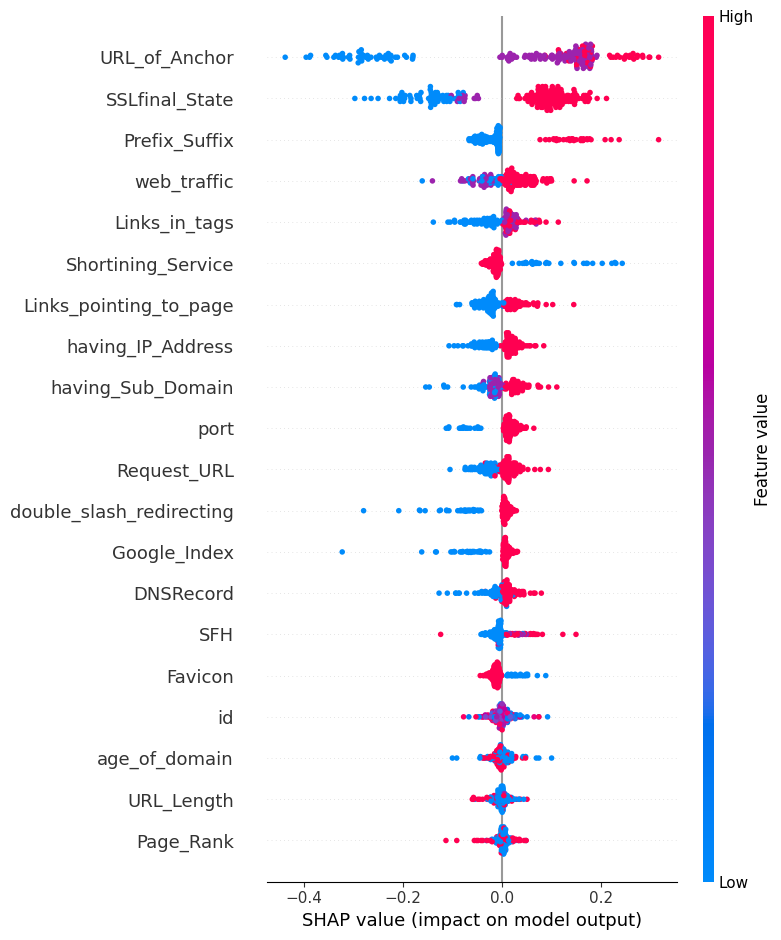

In [ ]:
import shap
# Use small background sample for speed
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

explainer = shap.Explainer(best_model, background)
X_sample = X_test[:200]

shap_values = explainer(X_sample)

shap.summary_plot(shap_values, X_sample, feature_names=X.columns)



In [ ]:
shap.initjs()

# If shap_values is returned as Explanation object
base_value = shap_values.base_values[0]
shap_value_single = shap_values.values[0]

shap.force_plot(
    base_value,
    shap_value_single,
    X_sample[0],
    feature_names=X.columns
)


**Update 2 cross validation for the best model 18/2/2025**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Result'] = df['Result'].replace(-1, 0)

X = df.drop('Result', axis=1).values
y = df['Result'].values

# Standardize FULL dataset (important for CV)
scaler = StandardScaler()
X = scaler.fit_transform(X)

input_dim = X.shape[1]

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# ======================================
# 2-FOLD CROSS VALIDATION
# ======================================

kf = KFold(n_splits=2, shuffle=True, random_state=42)

fold_accuracies = []

for fold, (train_index, test_index) in enumerate(kf.split(X), 1):

    print(f"\nTraining Fold {fold}")

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Create fresh model for each fold
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"Fold {fold} Accuracy: {acc:.4f}")
    fold_accuracies.append(acc)

# ======================================
# FINAL RESULT
# ======================================

average_accuracy = np.mean(fold_accuracies)

print("\n==============================")
print("2-Fold Cross Validation Accuracy:", round(average_accuracy, 4))
print("==============================")



Training Fold 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 Accuracy: 0.9405

Training Fold 2
Fold 2 Accuracy: 0.9522

2-Fold Cross Validation Accuracy: 0.9464


PermutationExplainer explainer: 201it [00:38,  4.08it/s]
/tmp/ipython-input-1774895083.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=feature_names)


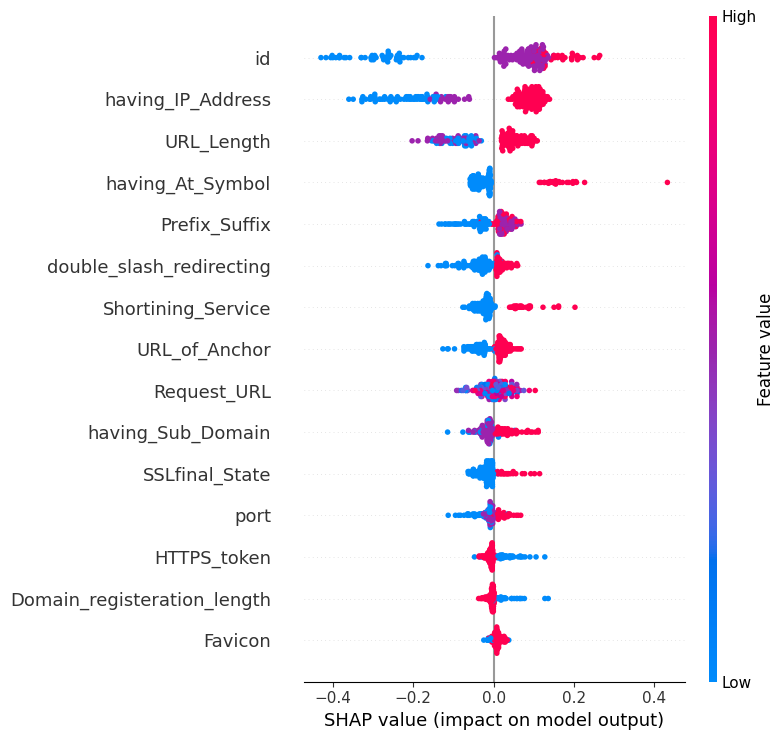

In [ ]:
import shap

# Keep feature names
feature_names = df.drop('Result', axis=1).columns

# Take sample
X_sample = X_test[:200]

# Create explainer
explainer = shap.Explainer(model, X_train)

# Get SHAP values
shap_values = explainer(X_sample)

# Summary plot with feature names
shap.summary_plot(shap_values, X_sample, feature_names=feature_names)


**Top 15 features of 2-cross validation 18/2/2025**


Training with Top 11 Features


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Top 11 Accuracy: 0.9313
Generating SHAP Summary Plot for Top 11 Features...


PermutationExplainer explainer: 201it [00:43,  3.79it/s]
/tmp/ipython-input-3298603401.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


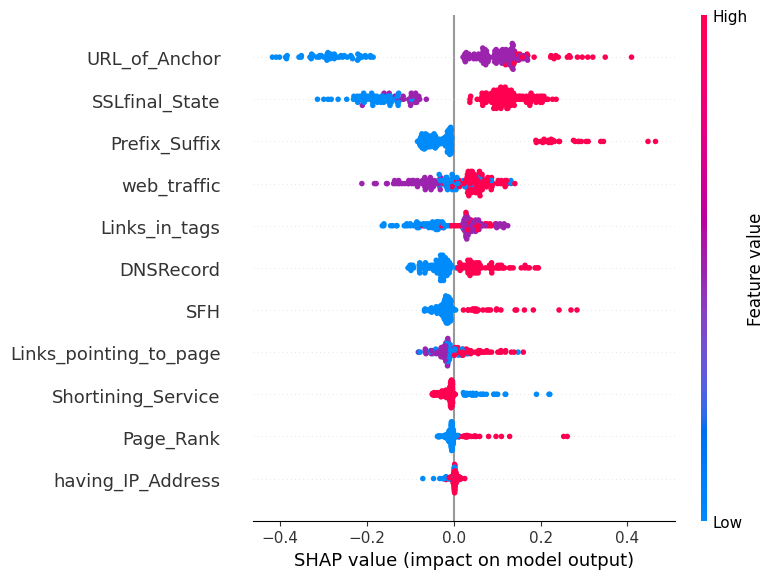


Training with Top 12 Features


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Top 12 Accuracy: 0.9354
Generating SHAP Summary Plot for Top 12 Features...


PermutationExplainer explainer: 201it [00:42,  3.65it/s]
/tmp/ipython-input-3298603401.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


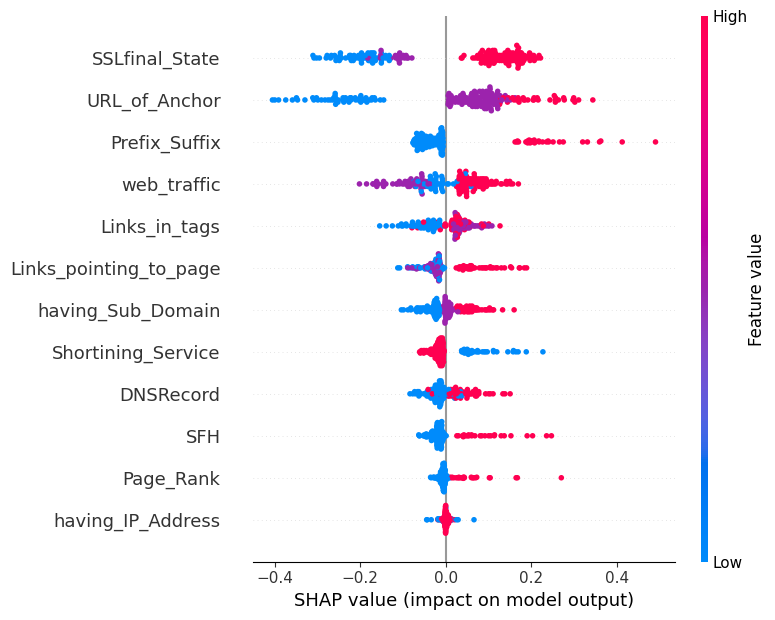


Training with Top 13 Features


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Top 13 Accuracy: 0.9386
Generating SHAP Summary Plot for Top 13 Features...


PermutationExplainer explainer: 201it [00:40,  3.64it/s]
/tmp/ipython-input-3298603401.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


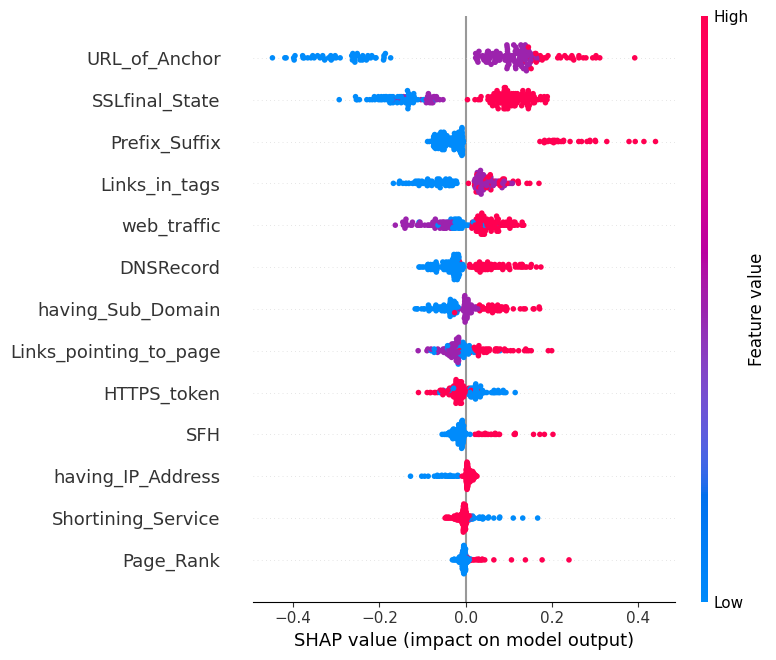


Training with Top 14 Features


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Top 14 Accuracy: 0.9410
Generating SHAP Summary Plot for Top 14 Features...


PermutationExplainer explainer: 201it [00:46,  3.21it/s]
/tmp/ipython-input-3298603401.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


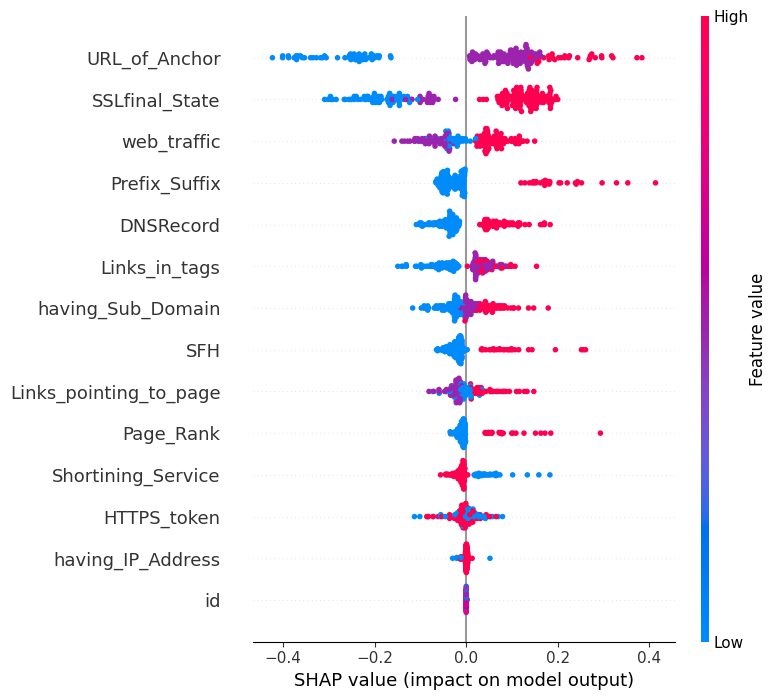


Training with Top 15 Features


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Top 15 Accuracy: 0.9425
Generating SHAP Summary Plot for Top 15 Features...


PermutationExplainer explainer: 201it [00:36,  3.91it/s]
/tmp/ipython-input-3298603401.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


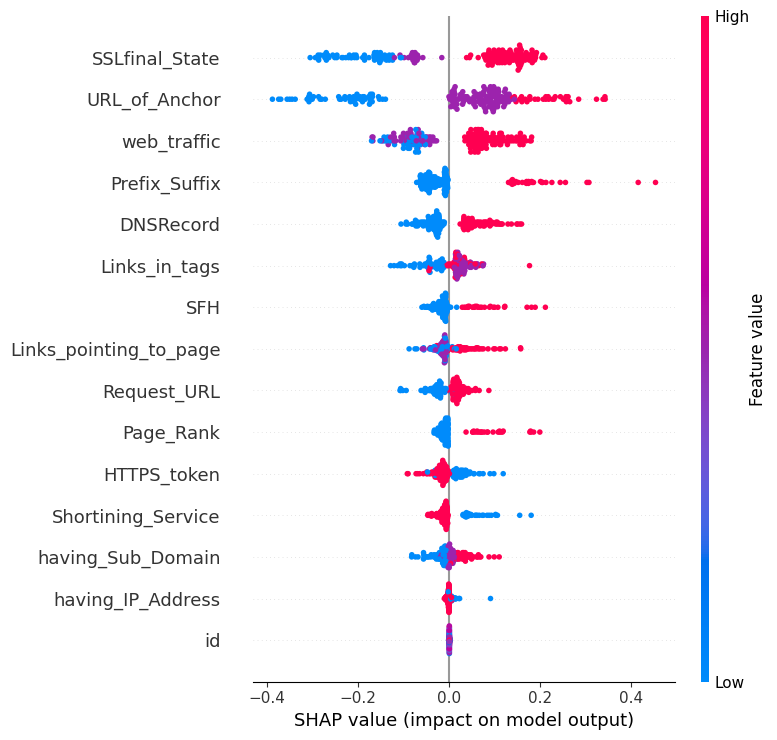


Best Feature Count: 15
Best Accuracy: 0.9425


In [ ]:
# ======================================
# IMPORTS
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf
import shap
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Result'] = df['Result'].replace(-1, 0)

# ======================================
# SHAP Ranked Features (Top 15)
# ======================================
ranked_features = [
    "URL_of_Anchor",
    "SSLfinal_State",
    "web_traffic",
    "SFH",
    "Prefix_Suffix",
    "DNSRecord",
    "Links_in_tags",
    "Links_pointing_to_page",
    "Page_Rank",
    "Shortining_Service",
    "having_IP_Address",
    "having_Sub_Domain",
    "HTTPS_token",
    "id",
    "Request_URL"
]

y = df['Result'].values
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

results = {}

# ======================================
# LOOP TOP 11 → TOP 15
# ======================================
for n in range(11, 16):

    print("\n===================================")
    print(f"Training with Top {n} Features")
    print("===================================")

    selected_features = ranked_features[:n]
    X = df[selected_features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    input_dim = X_scaled.shape[1]

    kf = KFold(n_splits=2, shuffle=True, random_state=42)
    fold_accuracies = []

    for train_index, test_index in kf.split(X_scaled):

        X_train, X_test = X_scaled[train_index], X_scaled[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model = Sequential([
            Dense(128, activation='relu', input_shape=(input_dim,)),
            BatchNormalization(),
            Dense(64, activation='relu'),
            Dense(1, activation='sigmoid')
        ])

        model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        model.fit(
            X_train, y_train,
            epochs=20,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stop],
            verbose=0
        )

        loss, acc = model.evaluate(X_test, y_test, verbose=0)
        fold_accuracies.append(acc)

    avg_accuracy = np.mean(fold_accuracies)
    results[n] = avg_accuracy

    print(f"Top {n} Accuracy: {avg_accuracy:.4f}")

    # ======================================
    # SHAP SUMMARY PLOT
    # ======================================
    print(f"Generating SHAP Summary Plot for Top {n} Features...")

    explainer = shap.Explainer(model, X_scaled[:200])
    shap_values = explainer(X_scaled[:200])

    shap.summary_plot(
        shap_values,
        X.iloc[:200],
        feature_names=selected_features
    )

# ======================================
# BEST RESULT
# ======================================
best_n = max(results, key=results.get)
best_acc = results[best_n]

print("\n===================================")
print("Best Feature Count:", best_n)
print("Best Accuracy:", round(best_acc, 4))
print("===================================")


**Balance | Feature selectionk=5 | parameter tuning | performance observation | cross validation
24/2/2025**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from imblearn.over_sampling import SMOTE

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Result'] = df['Result'].replace(-1, 0)

X = df.drop('Result', axis=1).values
y = df['Result'].values

# ======================================
# MODEL FUNCTION
# ======================================
def create_model(input_dim, learning_rate=0.001):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# ======================================
# 10-FOLD STRATIFIED CROSS VALIDATION
# ======================================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

learning_rates = [0.01, 0.001, 0.0005]

best_lr = 0
best_mean_acc = 0

for lr in learning_rates:
    print(f"\nTesting Learning Rate: {lr}")

    acc_list = []
    precision_list = []
    recall_list = []
    f1_list = []
    roc_list = []

    for train_index, test_index in skf.split(X, y):

        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # -----------------------------
        # SMOTE (only on training fold)
        # -----------------------------
        sm = SMOTE(random_state=42)
        X_train, y_train = sm.fit_resample(X_train, y_train)

        # -----------------------------
        # Scaling
        # -----------------------------
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # -----------------------------
        # Feature Selection
        # -----------------------------
        selector = SelectKBest(score_func=f_classif, k=20)
        X_train = selector.fit_transform(X_train, y_train)
        X_test = selector.transform(X_test)

        input_dim = X_train.shape[1]

        # -----------------------------
        # Model Training
        # -----------------------------
        model = create_model(input_dim, learning_rate=lr)

        model.fit(X_train, y_train,
                  epochs=30,
                  batch_size=32,
                  verbose=0,
                  callbacks=[early_stop])

        # -----------------------------
        # Prediction
        # -----------------------------
        y_pred_prob = model.predict(X_test)
        y_pred = (y_pred_prob > 0.5).astype(int)

        # -----------------------------
        # Metrics
        # -----------------------------
        acc_list.append(accuracy_score(y_test, y_pred))
        precision_list.append(precision_score(y_test, y_pred))
        recall_list.append(recall_score(y_test, y_pred))
        f1_list.append(f1_score(y_test, y_pred))
        roc_list.append(roc_auc_score(y_test, y_pred_prob))

    mean_acc = np.mean(acc_list)

    print("Mean Accuracy:", mean_acc)
    print("Mean Precision:", np.mean(precision_list))
    print("Mean Recall:", np.mean(recall_list))
    print("Mean F1-Score:", np.mean(f1_list))
    print("Mean ROC-AUC:", np.mean(roc_list))

    if mean_acc > best_mean_acc:
        best_mean_acc = mean_acc
        best_lr = lr

print("\n===================================")
print("BEST LEARNING RATE:", best_lr)
print("BEST CROSS-VALIDATED ACCURACY:", best_mean_acc)
print("===================================")

 **Applied Balanced technique of class weight
25/2/2025**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Result'] = df['Result'].replace(-1, 0)

X = df.drop('Result', axis=1)
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ======================================
# STANDARDIZE DATA
# ======================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

input_dim = X_train.shape[1]

# ======================================
# CLASS BALANCING (CLASS WEIGHTS)
# ======================================
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weights_dict)

# ======================================
# DEFINE BEST MODEL (DNN + BatchNorm)
# ======================================
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# ======================================
# TRAIN MODEL WITH CLASS WEIGHTS
# ======================================
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weights_dict,
    verbose=1
)

# ======================================
# EVALUATE MODEL
# ======================================
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print("\n==============================")
print("DNN + BatchNorm Accuracy:", acc)
print("==============================")

Class Weights: {0: np.float64(1.1286370597243491), 1: np.float64(0.8976857490864799)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8265 - loss: 0.3513 - val_accuracy: 0.9418 - val_loss: 0.1585
Epoch 2/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9348 - loss: 0.1604 - val_accuracy: 0.9486 - val_loss: 0.1282
Epoch 3/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9418 - loss: 0.1395 - val_accuracy: 0.9536 - val_loss: 0.1190
Epoch 4/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9501 - loss: 0.1262 - val_accuracy: 0.9621 - val_loss: 0.1041
Epoch 5/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9612 - loss: 0.1011 - val_accuracy: 0.9587 - val_loss: 0.1048
Epoch 6/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9575 - loss: 0.0943 - val_accuracy: 0.9587 - val_loss: 0.1063
Epoch 7/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9617 - loss: 0.0899 - val_accuracy: 0.9638 - val_loss: 0.0970
Epoch 8/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9695 - loss: 0.0786 - val_accuracy: 0

**Chi Square, pearson, select k best, information gain, jaccard similarity, for top 11 featues 27/2/2025**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import jaccard_score

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Result'] = df['Result'].replace(-1, 0)

X = df.drop('Result', axis=1)
y = df['Result']

feature_names = np.array(X.columns)

# ======================================
# 1️⃣ CHI-SQUARE (needs non-negative values)
# ======================================
X_chi = MinMaxScaler().fit_transform(X)

chi_selector = SelectKBest(score_func=chi2, k=11)
chi_selector.fit(X_chi, y)

chi_features = feature_names[chi_selector.get_support()]

# ======================================
# 2️⃣ PEARSON CORRELATION
# ======================================
pearson_scores = X.corrwith(y).abs()
pearson_features = pearson_scores.sort_values(ascending=False).head(11).index.tolist()

# ======================================
# 3️⃣ INFORMATION GAIN (Mutual Information)
# ======================================
mi_selector = SelectKBest(score_func=mutual_info_classif, k=11)
mi_selector.fit(X, y)

mi_features = feature_names[mi_selector.get_support()]

# ======================================
# 4️⃣ ANOVA (SelectKBest)
# ======================================
anova_selector = SelectKBest(score_func=f_classif, k=11)
anova_selector.fit(X, y)

anova_features = feature_names[anova_selector.get_support()]

# ======================================
# 5️⃣ JACCARD SIMILARITY (convert to binary)
# ======================================
X_binary = X.copy()

for col in X_binary.columns:
    X_binary[col] = (X_binary[col] > X_binary[col].median()).astype(int)

jaccard_scores = {}

for col in X_binary.columns:
    jaccard_scores[col] = jaccard_score(y, X_binary[col])

jaccard_features = sorted(jaccard_scores, key=jaccard_scores.get, reverse=True)[:11]

# ======================================
# PRINT RESULTS
# ======================================

print("\n==============================")
print("Top 11 Features - Chi Square")
print(list(chi_features))

print("\nTop 11 Features - Pearson")
print(pearson_features)

print("\nTop 11 Features - Information Gain")
print(list(mi_features))

print("\nTop 11 Features - ANOVA")
print(list(anova_features))

print("\nTop 11 Features - Jaccard")
print(jaccard_features)
print("==============================")


Top 11 Features - Chi Square
['Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'age_of_domain', 'web_traffic', 'Page_Rank']

Top 11 Features - Pearson
['SSLfinal_State', 'URL_of_Anchor', 'Prefix_Suffix', 'web_traffic', 'having_Sub_Domain', 'Request_URL', 'Links_in_tags', 'Domain_registeration_length', 'SFH', 'Google_Index', 'age_of_domain']

Top 11 Features - Information Gain
['id', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'web_traffic', 'Page_Rank']

Top 11 Features - ANOVA
['Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'age_of_domain', 'web_traffic', 'Google_Index']

Top 11 Features - Jaccard
['having_Sub_Domain', 'URL_of_Anchor', 'id', 'Links_pointing_to_page', 'SFH', 'Links_in_tags', 'Page_Ran

**Rank the Features 5/3/2026**

In [ ]:
from collections import Counter
import pandas as pd

# ======================================
# FEATURES FROM YOUR OUTPUT
# ======================================

chi_square = [
'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State',
'Domain_registeration_length', 'Request_URL', 'URL_of_Anchor',
'Links_in_tags', 'SFH', 'age_of_domain', 'web_traffic', 'Page_Rank'
]

pearson = [
'SSLfinal_State', 'URL_of_Anchor', 'Prefix_Suffix',
'web_traffic', 'having_Sub_Domain', 'Request_URL',
'Links_in_tags', 'Domain_registeration_length',
'SFH', 'Google_Index', 'age_of_domain'
]

information_gain = [
'id', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State',
'Domain_registeration_length', 'Request_URL', 'URL_of_Anchor',
'Links_in_tags', 'SFH', 'web_traffic', 'Page_Rank'
]

anova = [
'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State',
'Domain_registeration_length', 'Request_URL', 'URL_of_Anchor',
'Links_in_tags', 'SFH', 'age_of_domain', 'web_traffic', 'Google_Index'
]

jaccard = [
'having_Sub_Domain', 'URL_of_Anchor', 'id',
'Links_pointing_to_page', 'SFH', 'Links_in_tags',
'Page_Rank', 'Prefix_Suffix', 'URL_Length',
'Domain_registeration_length', 'Redirect'
]

# ======================================
# COMBINE ALL FEATURES
# ======================================

all_features = chi_square + pearson + information_gain + anova + jaccard

# Count occurrences
feature_counts = Counter(all_features)

# Convert to dataframe for ranking
ranking_df = pd.DataFrame(feature_counts.items(), columns=["Feature", "Score"])

# Sort by highest score
ranking_df = ranking_df.sort_values(by="Score", ascending=False)

# ======================================
# PRINT FINAL RANKING
# ======================================

print("\n==============================")
print("Feature Ranking Based on Method Frequency")
print("==============================")

print(ranking_df)

# Optional: Top 11 final features
print("\nTop Ranked Features")
print(ranking_df.head(11))


Feature Ranking Based on Method Frequency
                        Feature  Score
0                 Prefix_Suffix      5
1             having_Sub_Domain      5
3   Domain_registeration_length      5
5                 URL_of_Anchor      5
7                           SFH      5
6                 Links_in_tags      5
2                SSLfinal_State      4
4                   Request_URL      4
9                   web_traffic      4
8                 age_of_domain      3
10                    Page_Rank      3
11                 Google_Index      2
12                           id      2
13       Links_pointing_to_page      1
14                   URL_Length      1
15                     Redirect      1

Top Ranked Features
                        Feature  Score
0                 Prefix_Suffix      5
1             having_Sub_Domain      5
3   Domain_registeration_length      5
5                 URL_of_Anchor      5
7                           SFH      5
6                 Links_in_tags      5


**Top 5 rank Feature training model 5/3/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

# Remove unnecessary column
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Convert -1 to 0
df['Result'] = df['Result'].replace(-1, 0)

# ======================================
# SELECT TOP FEATURES
# ======================================
selected_features = [
    'Prefix_Suffix',
    'having_Sub_Domain',
    'Domain_registeration_length',
    'URL_of_Anchor',
    'SFH',
    'Links_in_tags'
]

X = df[selected_features]
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================
# APPLY SMOTE (BALANCING)
# ======================================
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE balancing:", np.bincount(y_train))

input_dim = X_train.shape[1]

# ======================================
# DNN + BatchNorm MODEL
# ======================================
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# ======================================
# TRAIN MODEL
# ======================================
model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ======================================
# EVALUATE MODEL
# ======================================
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print("\n==============================")
print("Model Accuracy with SMOTE:", acc)
print("==============================")

After SMOTE balancing: [4926 4926]
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8406 - loss: 0.3349 - val_accuracy: 0.8808 - val_loss: 0.2877
Epoch 2/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8718 - loss: 0.2725 - val_accuracy: 0.8635 - val_loss: 0.2730
Epoch 3/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8849 - loss: 0.2629 - val_accuracy: 0.8620 - val_loss: 0.2731
Epoch 4/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8785 - loss: 0.2575 - val_accuracy: 0.8595 - val_loss: 0.2605
Epoch 5/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8777 - loss: 0.2567 - val_accuracy: 0.8630 - val_loss: 0.2545
Epoch 6/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8849 - loss: 0.2479 - val_accuracy: 0.8579 - val_loss: 0.2672
Epoch 7/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8797 - loss: 0.2566 - val_accuracy: 0.8615 - val_loss: 0.2641
Epoch 8/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8804 - loss: 0.2616 - val_accuracy: 0.8615 - val

**Top 4 features of training 5/3/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Result'] = df['Result'].replace(-1, 0)

# ======================================
# SELECT TOP 4 FEATURES
# ======================================
selected_features = [
    'Prefix_Suffix',
    'having_Sub_Domain',
    'Domain_registeration_length',
    'URL_of_Anchor'
]

X = df[selected_features]
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================
# APPLY SMOTE
# ======================================
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE balancing:", np.bincount(y_train))

input_dim = X_train.shape[1]

# ======================================
# MODEL (DNN + BatchNorm)
# ======================================
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# ======================================
# TRAIN MODEL
# ======================================
model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ======================================
# EVALUATE MODEL
# ======================================
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print("\n==============================")
print("Model Accuracy with Top 4 Features:", acc)
print("==============================")

After SMOTE balancing: [4926 4926]
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8378 - loss: 0.3395 - val_accuracy: 0.8016 - val_loss: 0.3394
Epoch 2/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8504 - loss: 0.3080 - val_accuracy: 0.7991 - val_loss: 0.3161
Epoch 3/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8465 - loss: 0.3058 - val_accuracy: 0.8245 - val_loss: 0.3138
Epoch 4/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8506 - loss: 0.3023 - val_accuracy: 0.8245 - val_loss: 0.3255
Epoch 5/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8496 - loss: 0.2982 - val_accuracy: 0.8016 - val_loss: 0.3277
Epoch 6/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8518 - loss: 0.2928 - val_accuracy: 0.8016 - val_loss: 0.3183
Epoch 7/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8622 - loss: 0.2926 - val_accuracy: 0.8016 - val_loss: 0.3173
Epoch 8/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8517 - loss: 0.3040 - val_accuracy: 0.8016 - val_

**All Top Features 5/3/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Result'] = df['Result'].replace(-1, 0)

# ======================================
# SELECT FEATURES
# ======================================
selected_features = [
    'Prefix_Suffix',
    'having_Sub_Domain',
    'Domain_registeration_length',
    'URL_of_Anchor',
    'SFH',
    'Links_in_tags',
    'SSLfinal_State',
    'Request_URL',
    'web_traffic'
]

X = df[selected_features]
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================
# APPLY SMOTE (BALANCING)
# ======================================
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE balancing:", np.bincount(y_train))

input_dim = X_train.shape[1]

# ======================================
# MODEL (DNN + BatchNorm)
# ======================================
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ======================================
# TRAIN MODEL
# ======================================
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ======================================
# EVALUATE MODEL
# ======================================
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print("\n==============================")
print("Model Accuracy:", acc)
print("==============================")

After SMOTE balancing: [4926 4926]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8906 - loss: 0.2642 - val_accuracy: 0.9290 - val_loss: 0.1910
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9285 - loss: 0.1761 - val_accuracy: 0.9401 - val_loss: 0.1515
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9306 - loss: 0.1695 - val_accuracy: 0.9528 - val_loss: 0.1334
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9273 - loss: 0.1658 - val_accuracy: 0.9569 - val_loss: 0.1201
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9420 - loss: 0.1481 - val_accuracy: 0.9513 - val_loss: 0.1306
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9363 - loss: 0.1517 - val_accuracy: 0.9376 - val_loss: 0.1475
Epoch 7/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9382 - loss: 0.1434 - val_accuracy: 0.9482 - val_loss: 0.1324
Epoch 8/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9390 - loss: 0.1384 - val_accuracy: 0.

**Light Weight Transformer Learning 6/6/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, BatchNormalization,
    MultiHeadAttention, LayerNormalization,
    Dropout, Add, GlobalAveragePooling1D, Reshape
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Result'] = df['Result'].replace(-1, 0)

# ======================================
# SELECT FEATURES
# ======================================
selected_features = [
    'Prefix_Suffix',
    'having_Sub_Domain',
    'Domain_registeration_length',
    'URL_of_Anchor',
    'SFH',
    'Links_in_tags',
    'SSLfinal_State',
    'Request_URL',
    'web_traffic'
]

X = df[selected_features]
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================
# SMOTE BALANCING
# ======================================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE balancing:", np.bincount(y_train))

num_features = X_train.shape[1]

# ======================================
# HYBRID LIGHTWEIGHT TRANSFORMER
# ======================================
inputs = Input(shape=(num_features,))

# DNN Feature Encoder
x = Dense(128, activation="relu")(inputs)
x = BatchNormalization()(x)

x = Dense(64, activation="relu")(x)
x = BatchNormalization()(x)

# Convert to tokens
x = Reshape((8,8))(x)

# Lightweight Attention
attn = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)

x = Add()([x, attn])
x = LayerNormalization()(x)

# Feed Forward
ffn = Dense(64, activation="relu")(x)
ffn = Dense(8)(ffn)

x = Add()([x, ffn])
x = LayerNormalization()(x)

# Classification Head
x = GlobalAveragePooling1D()(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

# ======================================
# COMPILE
# ======================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ======================================
# EARLY STOPPING
# ======================================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# ======================================
# TRAIN
# ======================================
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ======================================
# EVALUATE
# ======================================
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print("\n==============================")
print("Model Accuracy:", acc)
print("==============================")

After SMOTE balancing: [4926 4926]


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 128)       │      1,280 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_29[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 64)        │      8,256 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_30[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 8, 8)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 8, 8)      │      2,248 │ reshape_5[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 8, 8)      │          0 │ reshape_5[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8)      │         16 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 8, 64)     │        576 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 8, 8)      │        520 │ dense_31[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 8, 8)      │          0 │ layer_normalizat… │
│                     │                   │            │ dense_32[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8)      │         16 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 8)         │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 64)        │        576 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64)        │          0 │ dense_33[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 1)         │         65 │ dropout_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,321 (55.94 KB)

 Trainable params: 13,937 (54.44 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8370 - loss: 0.4140 - val_accuracy: 0.9366 - val_loss: 0.1820
Epoch 2/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9257 - loss: 0.1950 - val_accuracy: 0.9396 - val_loss: 0.1549
Epoch 3/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9283 - loss: 0.1756 - val_accuracy: 0.9457 - val_loss: 0.1375
Epoch 4/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9365 - loss: 0.1612 - val_accuracy: 0.9462 - val_loss: 0.1351
Epoch 5/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9320 - loss: 0.1653 - val_accuracy: 0.9391 - val_loss: 0.1408
Epoch 6/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9363 - loss: 0.1500 - val_accuracy: 0.9391 - val_loss: 0.1481
Epoch 7/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9390 - loss: 0.1527 - val_accuracy: 0.9559 - val_loss: 0.1203
Epoch 8/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9379 - loss: 0.1496 - val_accuracy

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import jaccard_score

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Result'] = df['Result'].replace(-1, 0)

X = df.drop('Result', axis=1)
y = df['Result']

feature_names = np.array(X.columns)

# ======================================
# 1️⃣ CHI-SQUARE (needs non-negative values)
# ======================================
X_chi = MinMaxScaler().fit_transform(X)

chi_selector = SelectKBest(score_func=chi2, k=15)
chi_selector.fit(X_chi, y)

chi_features = feature_names[chi_selector.get_support()]

# ======================================
# 2️⃣ PEARSON CORRELATION
# ======================================
pearson_scores = X.corrwith(y).abs()
pearson_features = pearson_scores.sort_values(ascending=False).head(15).index.tolist()

# ======================================
# 3️⃣ INFORMATION GAIN (Mutual Information)
# ======================================
mi_selector = SelectKBest(score_func=mutual_info_classif, k=15)
mi_selector.fit(X, y)

mi_features = feature_names[mi_selector.get_support()]

# ======================================
# 4️⃣ ANOVA (SelectKBest)
# ======================================
anova_selector = SelectKBest(score_func=f_classif, k=15)
anova_selector.fit(X, y)

anova_features = feature_names[anova_selector.get_support()]

# ======================================
# 5️⃣ JACCARD SIMILARITY (convert to binary)
# ======================================
X_binary = X.copy()

for col in X_binary.columns:
    X_binary[col] = (X_binary[col] > X_binary[col].median()).astype(int)

jaccard_scores = {}

for col in X_binary.columns:
    jaccard_scores[col] = jaccard_score(y, X_binary[col])

jaccard_features = sorted(jaccard_scores, key=jaccard_scores.get, reverse=True)[:15]

# ======================================
# PRINT RESULTS
# ======================================

print("\n==============================")
print("Top 15 Features - Chi Square")
print(list(chi_features))

print("\nTop 15 Features - Pearson")
print(pearson_features)

print("\nTop 15 Features - Information Gain")
print(list(mi_features))

print("\nTop 15 Features - ANOVA")
print(list(anova_features))

print("\nTop 15 Features - Jaccard")
print(jaccard_features)
print("==============================")


Top 15 Features - Chi Square
['having_IP_Address', 'URL_Length', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index']

Top 15 Features - Pearson
['SSLfinal_State', 'URL_of_Anchor', 'Prefix_Suffix', 'web_traffic', 'having_Sub_Domain', 'Request_URL', 'Links_in_tags', 'Domain_registeration_length', 'SFH', 'Google_Index', 'age_of_domain', 'Page_Rank', 'having_IP_Address', 'Statistical_report', 'DNSRecord']

Top 15 Features - Information Gain
['id', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Abnormal_URL', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Statistical_report']

Top 15 Features - ANOVA
['having_IP_Address', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Request_URL'

**Machine Learning Gradient boost**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

# remove unnecessary column
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# convert labels
df['Result'] = df['Result'].replace(-1, 0)

# ======================================
# SELECT FEATURES
# ======================================
selected_features = [
    'Prefix_Suffix',
    'having_Sub_Domain',
    'Domain_registeration_length',
    'URL_of_Anchor',
    'Links_in_tags',
    'SFH',
    'Page_Rank',
    'SSLfinal_State',
    'Request_URL',
    'age_of_domain',
    'DNSRecord',
    'web_traffic',
    'having_IP_Address'
]

X = df[selected_features]
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================================
# LIGHTGBM MODEL
# ======================================
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42
)

# ======================================
# TRAIN MODEL
# ======================================
model.fit(X_train, y_train)

# ======================================
# PREDICTION
# ======================================
y_pred = model.predict(X_test)

# ======================================
# EVALUATION
# ======================================
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Number of positive: 4926, number of negative: 3918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006567 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 39
[LightGBM] [Info] Number of data points in the train set: 8844, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.556988 -> initscore=0.228946
[LightGBM] [Info] Start training from score 0.228946
Accuracy: 0.9629127091813658

Confusion Matrix
[[ 928   52]
 [  30 1201]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       980
           1       0.96      0.98      0.97      1231

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211



In [ ]:
# ======================================
import pandas as pd
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)
df.columns

Index(['id', 'having_IP_Address', 'URL_Length', 'Shortining_Service',
       'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix',
       'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length',
       'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor',
       'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL',
       'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe',
       'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank',
       'Google_Index', 'Links_pointing_to_page', 'Statistical_report',
       'Result'],
      dtype='object')

In [ ]:
df.shape

(11055, 32)

In [ ]:
df.dtypes

,0
id,int64
having_IP_Address,int64
URL_Length,int64
Shortining_Service,int64
having_At_Symbol,int64
double_slash_redirecting,int64
Prefix_Suffix,int64
having_Sub_Domain,int64
SSLfinal_State,int64
Domain_registeration_length,int64


**PCA Feature Extracted 1 10/03/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

# Remove unwanted column if exists
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# ======================================
# SPLIT FEATURES AND TARGET
# ======================================
X = df.drop(columns=['Result'])
y = df['Result']

# ======================================
# SCALE FEATURES
# ======================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ======================================
# APPLY PCA
# ======================================
pca = PCA()
pca.fit(X_scaled)

# ======================================
# CALCULATE FEATURE IMPORTANCE
# ======================================
importance = np.sum(np.abs(pca.components_), axis=0)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Score": importance
})

# Sort by importance
feature_importance = feature_importance.sort_values(by="Score", ascending=False)

print("Feature Ranking using PCA:")
print(feature_importance)

# ======================================
# SELECT TOP 15 FEATURES
# ======================================
top_features = feature_importance.head(15)['Feature']

print("\nTop 15 Features:")
print(top_features)

# ======================================
# CREATE NEW DATASET
# ======================================
df_pca = df[top_features]
df_pca['Result'] = y

# ======================================
# SAVE CSV
# ======================================
output_path = "/content/drive/MyDrive/pca_15_features_dataset.csv"
df_pca.to_csv(output_path, index=False)

print("\nNew dataset shape:", df_pca.shape)
print("CSV saved successfully")

Feature Ranking using PCA:
                        Feature     Score
1             having_IP_Address  4.252185
30           Statistical_report  4.235653
4              having_At_Symbol  4.231538
17          Submitting_to_email  4.211977
25                    DNSRecord  4.136926
19                     Redirect  4.116603
29       Links_pointing_to_page  3.982287
16                          SFH  3.961309
18                 Abnormal_URL  3.918386
20                 on_mouseover  3.914823
27                    Page_Rank  3.888274
6                 Prefix_Suffix  3.859275
9   Domain_registeration_length  3.858519
8                SSLfinal_State  3.835753
2                    URL_Length  3.784439
26                  web_traffic  3.751084
7             having_Sub_Domain  3.673566
13                  Request_URL  3.644292
11                         port  3.590588
14                URL_of_Anchor  3.475962
24                age_of_domain  3.474400
28                 Google_Index  3.415397
22     

/tmp/ipykernel_474/3725933446.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pca['Result'] = y



New dataset shape: (11055, 16)
CSV saved successfully


**LDA Feature Extracted 2 10/03/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

# Remove unwanted column
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# ======================================
# SPLIT FEATURES AND TARGET
# ======================================
X = df.drop(columns=['Result'])
y = df['Result']

# ======================================
# SCALE FEATURES
# ======================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ======================================
# APPLY LDA
# ======================================
lda = LinearDiscriminantAnalysis()
lda.fit(X_scaled, y)

# ======================================
# GET FEATURE IMPORTANCE
# ======================================
importance = np.abs(lda.coef_[0])

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Score": importance
})

# Sort features by importance
feature_importance = feature_importance.sort_values(by="Score", ascending=False)

print("Feature Ranking using LDA:")
print(feature_importance)

# ======================================
# SELECT TOP 15 FEATURES
# ======================================
top_features = feature_importance.head(15)['Feature']

print("\nTop 15 Features:")
print(top_features)

# ======================================
# CREATE NEW DATASET
# ======================================
df_lda = df[top_features]
df_lda['Result'] = y

# ======================================
# SAVE CSV
# ======================================
output_path = "/content/drive/MyDrive/lda_15_features_dataset.csv"
df_lda.to_csv(output_path, index=False)

print("\nNew dataset shape:", df_lda.shape)
print("CSV saved successfully")

Feature Ranking using LDA:
                        Feature     Score
8                SSLfinal_State  2.631922
14                URL_of_Anchor  2.348056
16                          SFH  0.667670
26                  web_traffic  0.633767
3            Shortining_Service  0.627675
15                Links_in_tags  0.617392
1             having_IP_Address  0.574942
6                 Prefix_Suffix  0.528705
7             having_Sub_Domain  0.493549
29       Links_pointing_to_page  0.481451
28                 Google_Index  0.457937
25                    DNSRecord  0.404526
13                  Request_URL  0.381264
19                     Redirect  0.357933
11                         port  0.293018
30           Statistical_report  0.273596
27                    Page_Rank  0.263077
5      double_slash_redirecting  0.261764
4              having_At_Symbol  0.257176
18                 Abnormal_URL  0.227649
12                  HTTPS_token  0.207696
10                      Favicon  0.188935
23     

/tmp/ipykernel_474/699789496.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lda['Result'] = y



New dataset shape: (11055, 16)
CSV saved successfully


In [ ]:
df11 = "/content/drive/MyDrive/lda_15_features_dataset.csv"
df12 = pd.read_csv(df11)

df12.columns


Index(['SSLfinal_State', 'URL_of_Anchor', 'SFH', 'web_traffic',
       'Shortining_Service', 'Links_in_tags', 'having_IP_Address',
       'Prefix_Suffix', 'having_Sub_Domain', 'Links_pointing_to_page',
       'Google_Index', 'DNSRecord', 'Request_URL', 'Redirect', 'port',
       'Result'],
      dtype='object')

In [ ]:
df12.shape

(11055, 16)

In [ ]:
df111 = "/content/drive/MyDrive/pca_15_features_dataset.csv"
df122 = pd.read_csv(df111)

df122.columns

Index(['having_IP_Address', 'Statistical_report', 'having_At_Symbol',
       'Submitting_to_email', 'DNSRecord', 'Redirect',
       'Links_pointing_to_page', 'SFH', 'Abnormal_URL', 'on_mouseover',
       'Page_Rank', 'Prefix_Suffix', 'Domain_registeration_length',
       'SSLfinal_State', 'URL_Length', 'Result'],
      dtype='object')

In [ ]:
df122.shape

(11055, 16)

**Original Dataset with Machine Learning models 10 Models trained 10/03/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

# ======================================
# LOAD DATASET
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

# ======================================
df['Result'] = df['Result'].replace(-1, 0)

X = df.drop(columns=['Result'])
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ======================================
# PRINT CLASS DISTRIBUTION BEFORE SMOTE
# ======================================
print("Class distribution BEFORE SMOTE:")
print(np.bincount(y_train))

# ======================================
# APPLY SMOTE
# ======================================
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

# ======================================
# PRINT CLASS DISTRIBUTION AFTER SMOTE
# ======================================
print("Class distribution AFTER SMOTE:")
print(np.bincount(y_train))

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================
# MACHINE LEARNING MODELS
# ======================================
models = {

"Logistic Regression": LogisticRegression(max_iter=2000),

"Decision Tree": DecisionTreeClassifier(),

"Random Forest": RandomForestClassifier(n_estimators=100),

"SVM": SVC(),

"KNN": KNeighborsClassifier(),

"Naive Bayes": GaussianNB(),

"Gradient Boosting": GradientBoostingClassifier(),

"Extra Trees": ExtraTreesClassifier(n_estimators=100),

"XGBoost": XGBClassifier(eval_metric='logloss')

}

# ======================================
# TRAIN AND EVALUATE MODELS
# ======================================
print("\n======== MACHINE LEARNING RESULTS ========")

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    results.append((name, acc))

    print(name, "Accuracy:", acc)

# ======================================
# RESULT TABLE
# ======================================
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])

print("\nModel Comparison Table")
print(results_df.sort_values(by="Accuracy", ascending=False))

# ======================================
# BEST MODEL
# ======================================
best_model = results_df.loc[results_df['Accuracy'].idxmax()]

print("\n===== Original Dataset BEST MODEL =====")
print("Best Model :", best_model["Model"])
print("Best Accuracy :", best_model["Accuracy"])

Class distribution BEFORE SMOTE:
[3942 4902]
Class distribution AFTER SMOTE:
[4902 4902]

======== MACHINE LEARNING RESULTS ========
Logistic Regression Accuracy: 0.921302578018996
Decision Tree Accuracy: 0.9538670284938942
Random Forest Accuracy: 0.9642695612844867
SVM Accuracy: 0.9538670284938942
KNN Accuracy: 0.945273631840796
Naive Bayes Accuracy: 0.5866123925825418
Gradient Boosting Accuracy: 0.9479873360470376
Extra Trees Accuracy: 0.9624604251469923
XGBoost Accuracy: 0.9669832654907282

Model Comparison Table
                 Model  Accuracy
8              XGBoost  0.966983
2        Random Forest  0.964270
7          Extra Trees  0.962460
3                  SVM  0.953867
1        Decision Tree  0.953867
6    Gradient Boosting  0.947987
4                  KNN  0.945274
0  Logistic Regression  0.921303
5          Naive Bayes  0.586612

===== Original Dataset BEST MODEL =====
Best Model : XGBoost
Best Accuracy : 0.9669832654907282


**Original Dataset trained using Deep Learning 10/03/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Result'] = df['Result'].replace(-1, 0)

X = df.drop('Result', axis=1)
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

input_dim = X_train.shape[1]

early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

# ======================================
# DNN + BATCH NORMALIZATION MODEL
# ======================================
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# ======================================
# COMPILE MODEL
# ======================================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ======================================
# TRAIN MODEL
# ======================================
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ======================================
# EVALUATE MODEL
# ======================================
loss, accuracy = model.evaluate(X_test, y_test)

print("\n=======================")
print("DNN + BatchNorm Accuracy:", accuracy)
print("=======================")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8425 - loss: 0.3304 - val_accuracy: 0.9497 - val_loss: 0.1605
Epoch 2/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9323 - loss: 0.1546 - val_accuracy: 0.9469 - val_loss: 0.1298
Epoch 3/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9489 - loss: 0.1295 - val_accuracy: 0.9570 - val_loss: 0.1191
Epoch 4/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9488 - loss: 0.1190 - val_accuracy: 0.9536 - val_loss: 0.1120
Epoch 5/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9590 - loss: 0.0968 - val_accuracy: 0.9553 - val_loss: 0.1104
Epoch 6/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9634 - loss: 0.0978 - val_accuracy: 0.9570 - val_loss: 0.1106
Epoch 7/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9650 - loss: 0.0924 - val_accuracy: 0.9599 - val_loss: 0.1056
Epoch 8/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9664 - loss: 0.0815 - val_accuracy: 0.9593 - va

**PCA Extracted Features with Machine Learning models 10/03/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier

# SMOTE
from imblearn.over_sampling import SMOTE

# ======================================
# LOAD DATASET
# ======================================
path = "/content/drive/MyDrive/pca_15_features_dataset.csv"
df = pd.read_csv(path)

# ======================================
# FIX TARGET VALUES
# ======================================
df['Result'] = df['Result'].replace(-1, 0)

X = df.drop(columns=['Result'])
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ======================================
# CLASS DISTRIBUTION BEFORE SMOTE
# ======================================
print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())

# ======================================
# APPLY SMOTE
# ======================================
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

# ======================================
# CLASS DISTRIBUTION AFTER SMOTE
# ======================================
print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train).value_counts())

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================
# MACHINE LEARNING MODELS
# ======================================
models = {

"Logistic Regression": LogisticRegression(max_iter=2000),

"Decision Tree": DecisionTreeClassifier(),

"Random Forest": RandomForestClassifier(n_estimators=100),

"SVM": SVC(),

"KNN": KNeighborsClassifier(),

"Naive Bayes": GaussianNB(),

"Gradient Boosting": GradientBoostingClassifier(),

"Extra Trees": ExtraTreesClassifier(n_estimators=100),

"XGBoost": XGBClassifier(eval_metric='logloss')

}

print("\n======== MACHINE LEARNING RESULTS ========")

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    results.append((name, acc))

    print(name, "Accuracy:", acc)

# ======================================
# RESULT TABLE
# ======================================
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])

print("\nModel Comparison Table")
print(results_df.sort_values(by="Accuracy", ascending=False))

# ======================================
# BEST MODEL
# ======================================
best_model = results_df.loc[results_df['Accuracy'].idxmax()]

print("\n===== BEST MODEL =====")
print("Best Model :", best_model["Model"])
print("Best Accuracy :", best_model["Accuracy"])

Class distribution BEFORE SMOTE:
Result
1    4902
0    3942
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Result
1    4902
0    4902
Name: count, dtype: int64

======== MACHINE LEARNING RESULTS ========
Logistic Regression Accuracy: 0.8950701040253279
Decision Tree Accuracy: 0.9208502939846224
Random Forest Accuracy: 0.9240162822252375
SVM Accuracy: 0.9185888738127544
KNN Accuracy: 0.8937132519222072
Naive Bayes Accuracy: 0.5581184984170059
Gradient Boosting Accuracy: 0.9109000452284034
Extra Trees Accuracy: 0.9249208502939846
XGBoost Accuracy: 0.924468566259611

Model Comparison Table
                 Model  Accuracy
7          Extra Trees  0.924921
8              XGBoost  0.924469
2        Random Forest  0.924016
1        Decision Tree  0.920850
3                  SVM  0.918589
6    Gradient Boosting  0.910900
0  Logistic Regression  0.895070
4                  KNN  0.893713
5          Naive Bayes  0.558118

===== BEST MODEL =====
Best Model : Extra Trees
Best Accuracy :

**PCA Extracted Features With Deep Learning Model 10/03/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ======================================
# LOAD PCA DATASET
# ======================================
path = "/content/drive/MyDrive/pca_15_features_dataset.csv"
df = pd.read_csv(path)

# FIX TARGET LABELS
df['Result'] = df['Result'].replace(-1, 0)

# ======================================
# SPLIT FEATURES AND TARGET
# ======================================
X = df.drop(columns=['Result'])
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================
# APPLY SMOTE
# ======================================
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE balancing:", np.bincount(y_train))

input_dim = X_train.shape[1]

# ======================================
# MODEL
# ======================================
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),

    Dense(64, activation='relu'),
    BatchNormalization(),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# ======================================
# TRAIN
# ======================================
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ======================================
# EVALUATE
# ======================================
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print("\n==============================")
print("DNN + BatchNorm Accuracy:", acc)
print("==============================")

After SMOTE balancing: [4926 4926]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.8174 - loss: 0.4201 - val_accuracy: 0.9148 - val_loss: 0.2656
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8928 - loss: 0.2769 - val_accuracy: 0.9132 - val_loss: 0.2352
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8993 - loss: 0.2549 - val_accuracy: 0.9188 - val_loss: 0.2231
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9058 - loss: 0.2388 - val_accuracy: 0.9214 - val_loss: 0.2170
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9145 - loss: 0.2238 - val_accuracy: 0.9092 - val_loss: 0.2207
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9171 - loss: 0.2237 - val_accuracy: 0.9239 - val_loss: 0.2163
Epoch 7/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9036 - loss: 0.2345 - val_accuracy: 0.9285 - val_loss: 0.1984
Epoch 8/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9174 - loss: 0.2206 - val_accuracy

**LDA Extracted Features with LDA Model 10/03/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/lda_15_features_dataset.csv"
df = pd.read_csv(path)

# ======================================
# SPLIT FEATURES AND TARGET
# ======================================
X = df.drop(columns=['Result'])
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================
# LDA MODEL
# ======================================
lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X_train, y_train)

# ======================================
# PREDICTIONS
# ======================================
y_pred = lda_model.predict(X_test)

# ======================================
# EVALUATION
# ======================================
accuracy = accuracy_score(y_test, y_pred)

print("=================================")
print("LDA Model Accuracy:", accuracy)
print("=================================\n")

print("Classification Report\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

LDA Model Accuracy: 0.9231117141564903

Classification Report

              precision    recall  f1-score   support

          -1       0.93      0.89      0.91       980
           1       0.92      0.95      0.93      1231

    accuracy                           0.92      2211
   macro avg       0.92      0.92      0.92      2211
weighted avg       0.92      0.92      0.92      2211

Confusion Matrix

[[ 875  105]
 [  65 1166]]


**LDA Feature Extracted with Machine Learning model 10/06/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# ML MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier

# SMOTE
from imblearn.over_sampling import SMOTE

# ======================================
# LOAD LDA DATASET
# ======================================
path = "/content/drive/MyDrive/lda_15_features_dataset.csv"
df = pd.read_csv(path)

# ======================================
# FIX LABEL VALUES
# ======================================
df['Result'] = df['Result'].replace(-1, 0)

X = df.drop(columns=['Result'])
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================================
# CLASS DISTRIBUTION BEFORE SMOTE
# ======================================
print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())

# ======================================
# APPLY SMOTE
# ======================================
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

# ======================================
# CLASS DISTRIBUTION AFTER SMOTE
# ======================================
print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train).value_counts())

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================
# DEFINE MODELS
# ======================================
models = {

"Logistic Regression": LogisticRegression(max_iter=2000),

"Decision Tree": DecisionTreeClassifier(),

"Random Forest": RandomForestClassifier(n_estimators=100),

"SVM": SVC(),

"KNN": KNeighborsClassifier(),

"Naive Bayes": GaussianNB(),

"Gradient Boosting": GradientBoostingClassifier(),

"Extra Trees": ExtraTreesClassifier(n_estimators=100),

"XGBoost": XGBClassifier(eval_metric='logloss')

}

# ======================================
# TRAIN AND EVALUATE
# ======================================
results = []

print("\n===== MODEL RESULTS =====\n")

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results.append((name, acc))

    print(name, "Accuracy:", acc)

# ======================================
# RESULT COMPARISON TABLE
# ======================================
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])

print("\n===== MODEL COMPARISON =====")
print(results_df.sort_values(by="Accuracy", ascending=False))

# ======================================
# BEST MODEL
# ======================================
best_model = results_df.loc[results_df['Accuracy'].idxmax()]

print("\n===== BEST MODEL =====")
print("Best Model :", best_model["Model"])
print("Best Accuracy :", best_model["Accuracy"])

Class distribution BEFORE SMOTE:
Result
1    4926
0    3918
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Result
0    4926
1    4926
Name: count, dtype: int64

===== MODEL RESULTS =====

Logistic Regression Accuracy: 0.9317051108095884
Decision Tree Accuracy: 0.9597467209407508
Random Forest Accuracy: 0.9656264133876075
SVM Accuracy: 0.9516056083220262
KNN Accuracy: 0.945273631840796
Naive Bayes Accuracy: 0.5870646766169154
Gradient Boosting Accuracy: 0.9507010402532791
Extra Trees Accuracy: 0.9642695612844867
XGBoost Accuracy: 0.9624604251469923

===== MODEL COMPARISON =====
                 Model  Accuracy
2        Random Forest  0.965626
7          Extra Trees  0.964270
8              XGBoost  0.962460
1        Decision Tree  0.959747
3                  SVM  0.951606
6    Gradient Boosting  0.950701
4                  KNN  0.945274
0  Logistic Regression  0.931705
5          Naive Bayes  0.587065

===== BEST MODEL =====
Best Model : Random Forest
Best Accuracy : 0.96562

**LDA Feature Extracted with Deep Learning Model 10/03/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ======================================
# LOAD LDA DATASET
# ======================================
path = "/content/drive/MyDrive/lda_15_features_dataset.csv"
df = pd.read_csv(path)

# FIX TARGET LABELS
df['Result'] = df['Result'].replace(-1, 0)

# ======================================
# SPLIT FEATURES AND TARGET
# ======================================
X = df.drop(columns=['Result'])
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================
# APPLY SMOTE
# ======================================
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE balancing:", np.bincount(y_train))

input_dim = X_train.shape[1]

# ======================================
# DNN MODEL WITH BATCH NORMALIZATION
# ======================================
model = Sequential([

    Dense(64, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),

    Dense(32, activation='relu'),
    BatchNormalization(),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')

])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

# ======================================
# TRAIN MODEL
# ======================================
model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ======================================
# EVALUATE MODEL
# ======================================
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print("\n==============================")
print("DNN + BatchNorm Accuracy:", acc)
print("==============================")

After SMOTE balancing: [4926 4926]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8338 - loss: 0.3540 - val_accuracy: 0.9264 - val_loss: 0.1798
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9189 - loss: 0.1956 - val_accuracy: 0.9396 - val_loss: 0.1497
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9348 - loss: 0.1624 - val_accuracy: 0.9391 - val_loss: 0.1356
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9348 - loss: 0.1490 - val_accuracy: 0.9386 - val_loss: 0.1386
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9422 - loss: 0.1422 - val_accuracy: 0.9538 - val_loss: 0.1145
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9366 - loss: 0.1450 - val_accuracy: 0.9493 - val_loss: 0.1144
Epoch 7/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9450 - loss: 0.1310 - val_accuracy: 0.9518 - val_loss: 0.1116
Epoch 8/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9471 - loss: 0.1273 - val_accura

**PCA 20 Featues extracted 10/03/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

# Remove unwanted column if exists
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# ======================================
# SPLIT FEATURES AND TARGET
# ======================================
X = df.drop(columns=['Result'])
y = df['Result']

# ======================================
# SCALE FEATURES
# ======================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ======================================
# APPLY PCA
# ======================================
pca = PCA()
pca.fit(X_scaled)

# ======================================
# CALCULATE FEATURE IMPORTANCE
# ======================================
importance = np.sum(np.abs(pca.components_), axis=0)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Score": importance
})

# Sort by importance
feature_importance = feature_importance.sort_values(by="Score", ascending=False)

print("Feature Ranking using PCA:")
print(feature_importance)

# ======================================
# SELECT TOP 15 FEATURES
# ======================================
top_features = feature_importance.head(20)['Feature']

print("\nTop 15 Features:")
print(top_features)

# ======================================
# CREATE NEW DATASET
# ======================================
df_pca = df[top_features]
df_pca['Result'] = y

# ======================================
# SAVE CSV
# ======================================
output_path = "/content/drive/MyDrive/pca dataset of 20.csv"
df_pca.to_csv(output_path, index=False)

print("\nNew dataset shape:", df_pca.shape)
print("CSV saved successfully")

Feature Ranking using PCA:
                        Feature     Score
1             having_IP_Address  4.252185
30           Statistical_report  4.235653
4              having_At_Symbol  4.231538
17          Submitting_to_email  4.211977
25                    DNSRecord  4.136926
19                     Redirect  4.116603
29       Links_pointing_to_page  3.982287
16                          SFH  3.961309
18                 Abnormal_URL  3.918386
20                 on_mouseover  3.914823
27                    Page_Rank  3.888274
6                 Prefix_Suffix  3.859275
9   Domain_registeration_length  3.858519
8                SSLfinal_State  3.835753
2                    URL_Length  3.784439
26                  web_traffic  3.751084
7             having_Sub_Domain  3.673566
13                  Request_URL  3.644292
11                         port  3.590588
14                URL_of_Anchor  3.475962
24                age_of_domain  3.474400
28                 Google_Index  3.415397
22     

/tmp/ipykernel_474/2642378973.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pca['Result'] = y



New dataset shape: (11055, 21)
CSV saved successfully


**PCA with 20 selected Features with Deep Learning 10/03/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ======================================
# LOAD PCA DATASET
# ======================================
path = "/content/drive/MyDrive/pca dataset of 20.csv"
df = pd.read_csv(path)

# FIX TARGET LABELS
df['Result'] = df['Result'].replace(-1, 0)

# ======================================
# SPLIT FEATURES AND TARGET
# ======================================
X = df.drop(columns=['Result'])
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================
# APPLY SMOTE
# ======================================
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE balancing:", np.bincount(y_train))

input_dim = X_train.shape[1]

# ======================================
# MODEL
# ======================================
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),

    Dense(64, activation='relu'),
    BatchNormalization(),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# ======================================
# TRAIN
# ======================================
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ======================================
# EVALUATE
# ======================================
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print("\n==============================")
print("DNN + BatchNorm Accuracy:", acc)
print("==============================")

After SMOTE balancing: [4926 4926]
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


247/247 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8168 - loss: 0.3948 - val_accuracy: 0.9224 - val_loss: 0.1796
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9233 - loss: 0.1785 - val_accuracy: 0.9533 - val_loss: 0.1249
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9374 - loss: 0.1509 - val_accuracy: 0.9554 - val_loss: 0.1203
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9405 - loss: 0.1411 - val_accuracy: 0.9584 - val_loss: 0.1046
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9438 - loss: 0.1301 - val_accuracy: 0.9437 - val_loss: 0.1227
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9500 - loss: 0.1171 - val_accuracy: 0.9554 - val_loss: 0.1039
Epoch 7/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9591 - loss: 0.1039 - val_accuracy: 0.9543 - val_loss: 0.1010
Epoch 8/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9497 - loss: 0.1171 - val_accuracy: 0.9614 - val_

**LDA 20 Featues extracted 10/03/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

# Remove unwanted column
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# ======================================
# SPLIT FEATURES AND TARGET
# ======================================
X = df.drop(columns=['Result'])
y = df['Result']

# ======================================
# SCALE FEATURES
# ======================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ======================================
# APPLY LDA
# ======================================
lda = LinearDiscriminantAnalysis()
lda.fit(X_scaled, y)

# ======================================
# GET FEATURE IMPORTANCE
# ======================================
importance = np.abs(lda.coef_[0])

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Score": importance
})

# Sort features by importance
feature_importance = feature_importance.sort_values(by="Score", ascending=False)

print("Feature Ranking using LDA:")
print(feature_importance)

# ======================================
# SELECT TOP 15 FEATURES
# ======================================
top_features = feature_importance.head(20)['Feature']

print("\nTop 15 Features:")
print(top_features)

# ======================================
# CREATE NEW DATASET
# ======================================
df_lda = df[top_features]
df_lda['Result'] = y

# ======================================
# SAVE CSV
# ======================================
output_path = "/content/drive/MyDrive/lda 20 dataset.csv"
df_lda.to_csv(output_path, index=False)

print("\nNew dataset shape:", df_lda.shape)
print("CSV saved successfully")

Feature Ranking using LDA:
                        Feature     Score
8                SSLfinal_State  2.631922
14                URL_of_Anchor  2.348056
16                          SFH  0.667670
26                  web_traffic  0.633767
3            Shortining_Service  0.627675
15                Links_in_tags  0.617392
1             having_IP_Address  0.574942
6                 Prefix_Suffix  0.528705
7             having_Sub_Domain  0.493549
29       Links_pointing_to_page  0.481451
28                 Google_Index  0.457937
25                    DNSRecord  0.404526
13                  Request_URL  0.381264
19                     Redirect  0.357933
11                         port  0.293018
30           Statistical_report  0.273596
27                    Page_Rank  0.263077
5      double_slash_redirecting  0.261764
4              having_At_Symbol  0.257176
18                 Abnormal_URL  0.227649
12                  HTTPS_token  0.207696
10                      Favicon  0.188935
23     

/tmp/ipykernel_474/1229928372.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lda['Result'] = y



New dataset shape: (11055, 21)
CSV saved successfully


**LDA with 20 selected Features with Deep Learning 10/03/2026**

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ======================================
# LOAD LDA DATASET
# ======================================
path = "/content/drive/MyDrive/lda 20 dataset.csv"
df = pd.read_csv(path)

# FIX TARGET LABELS
df['Result'] = df['Result'].replace(-1, 0)

# ======================================
# SPLIT FEATURES AND TARGET
# ======================================
X = df.drop(columns=['Result'])
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================
# APPLY SMOTE
# ======================================
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE balancing:", np.bincount(y_train))

input_dim = X_train.shape[1]

# ======================================
# DNN MODEL WITH BATCH NORMALIZATION
# ======================================
model = Sequential([

    Dense(64, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),

    Dense(32, activation='relu'),
    BatchNormalization(),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')

])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

# ======================================
# TRAIN MODEL
# ======================================
model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ======================================
# EVALUATE MODEL
# ======================================
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print("\n==============================")
print("DNN + BatchNorm Accuracy:", acc)
print("==============================")

After SMOTE balancing: [4926 4926]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8798 - loss: 0.2757 - val_accuracy: 0.9330 - val_loss: 0.1736
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9237 - loss: 0.1879 - val_accuracy: 0.9406 - val_loss: 0.1441
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9329 - loss: 0.1609 - val_accuracy: 0.9391 - val_loss: 0.1436
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9362 - loss: 0.1539 - val_accuracy: 0.9467 - val_loss: 0.1296
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9414 - loss: 0.1441 - val_accuracy: 0.9462 - val_loss: 0.1235
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9434 - loss: 0.1318 - val_accuracy: 0.9498 - val_loss: 0.1160
Epoch 7/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9448 - loss: 0.1319 - val_accuracy: 0.9477 - val_loss: 0.1200
Epoch 8/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9459 - loss: 0.1252 - val_accuracy: 

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Result'] = df['Result'].replace(-1, 0)

X = df.drop('Result', axis=1)
y = df['Result']

# ======================================
# TRAIN TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

input_dim = X_train.shape[1]

early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

# ======================================
# DNN + BATCH NORMALIZATION MODEL
# ======================================
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# ======================================
# COMPILE MODEL
# ======================================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ======================================
# TRAIN MODEL
# ======================================
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ======================================
# EVALUATE MODEL
# ======================================
loss, accuracy = model.evaluate(X_test, y_test)

print("\n=======================")
print("DNN + BatchNorm Accuracy:", accuracy)
print("=======================")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8965 - loss: 0.2350 - val_accuracy: 0.9361 - val_loss: 0.1653
Epoch 2/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9354 - loss: 0.1524 - val_accuracy: 0.9503 - val_loss: 0.1338
Epoch 3/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9433 - loss: 0.1330 - val_accuracy: 0.9553 - val_loss: 0.1205
Epoch 4/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9500 - loss: 0.1212 - val_accuracy: 0.9525 - val_loss: 0.1153
Epoch 5/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9567 - loss: 0.1041 - val_accuracy: 0.9616 - val_loss: 0.1087
Epoch 6/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9570 - loss: 0.1020 - val_accuracy: 0.9627 - val_loss: 0.1086
Epoch 7/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9601 - loss: 0.0966 - val_accuracy: 0.9633 - val_loss: 0.1004
Epoch 8/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9651 - loss: 0.0871 - val_accuracy: 0.9610 - val_

In [ ]:
df.shape

(11055, 32)

In [ ]:
df.columns

Index(['id', 'having_IP_Address', 'URL_Length', 'Shortining_Service',
       'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix',
       'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length',
       'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor',
       'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL',
       'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe',
       'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank',
       'Google_Index', 'Links_pointing_to_page', 'Statistical_report',
       'Result'],
      dtype='object')

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import tensorflow as tf
import joblib

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ======================================
# LOAD DATA
# ======================================
path = "/content/drive/MyDrive/csv_result-Training Dataset.csv"
df = pd.read_csv(path)

# Convert labels (-1 → 0) for binary classification
df['Result'] = df['Result'].replace(-1, 0)

# ======================================
#  FAST EXTRACTION FEATURES
# ======================================
# We are dropping the slow HTML/Traffic features and keeping the 12 fast ones.
fast_features = [
    'having_IP_Address',
    'URL_Length',
    'Shortining_Service',
    'having_At_Symbol',
    'double_slash_redirecting',
    'Prefix_Suffix',
    'having_Sub_Domain',
    'HTTPS_token',
    'Abnormal_URL',
    'Domain_registeration_length',
    'age_of_domain',
    'DNSRecord'
]

X = df[fast_features]
y = df['Result']

# ======================================
# TRAIN, VALIDATION, AND TEST SPLIT
# ======================================
# 1. First split out the final holdout TEST set (20%)
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Now split the remaining data into TRAIN and VALIDATION sets (80/20)
# This ensures synthetic SMOTE data never leaks into our validation set!
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, random_state=42, stratify=y_train_temp
)

# ======================================
# FEATURE SCALING
# ======================================
scaler = StandardScaler()

# Fit only on the training data, then transform all three sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for your real-time extraction pipeline later
joblib.dump(scaler, 'url_scaler.pkl')
print(" Scaler saved as 'url_scaler.pkl'")

# ======================================
# HANDLE CLASS IMBALANCE (SMOTE)
# ======================================
smote = SMOTE(random_state=42)

# Apply SMOTE strictly to the training data!
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Class balance before SMOTE:", np.bincount(y_train))
print("Class balance after SMOTE: ", np.bincount(y_train_smote))

# ======================================
#  DNN + BATCH NORMALIZATION MODEL
# ======================================
input_dim = X_train_smote.shape[1]

model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')   # Binary output for probability
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ======================================
# EARLY STOPPING
# ======================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ======================================
# TRAIN MODEL
# ======================================
# Notice we are using validation_data instead of validation_split here
history = model.fit(
    X_train_smote, y_train_smote,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stop],
    verbose=1
)

# ======================================
# EVALUATE & SAVE MODEL
# ======================================
loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)

print("\n==============================")
print(f"Final Test Accuracy: {acc:.4f}")
print("==============================")

# Save the model for real-time predictions
model.save('phishing_dnn_model.h5')
print("✅ Model saved as 'phishing_dnn_model.h5'")

✅ Scaler saved as 'url_scaler.pkl'
Class balance before SMOTE: [3134 3941]
Class balance after SMOTE:  [3941 3941]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7135 - loss: 0.5510 - val_accuracy: 0.6976 - val_loss: 0.5464
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7452 - loss: 0.5074 - val_accuracy: 0.7462 - val_loss: 0.4948
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7563 - loss: 0.4952 - val_accuracy: 0.7428 - val_loss: 0.4957
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7572 - loss: 0.4873 - val_accuracy: 0.7513 - val_loss: 0.5034
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7620 - loss: 0.4792 - val_accuracy: 0.7592 - val_loss: 0.4962
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7673 - loss: 0.4743 - val_accuracy: 0.7507 - val_loss: 0.4931
Epoch 7/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7678 - loss: 0.4703 - val_accuracy: 0.7564 - val_loss: 0.4842
Epoch 8/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7718 - loss: 0.4671 - val_accuracy: 0.


Final Test Accuracy: 0.7639
✅ Model saved as 'phishing_dnn_model.h5'


In [ ]:
# corrected code 3
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, MaxPooling1D,
    Bidirectional, LSTM, Dense, Dropout
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score  # Added this import
import joblib

# 1. LOAD AND MERGE DATASETS optional but we can use this ml model
def load_and_normalize():
    # Dataset 1: Dataset.csv (url, label)
    df1 = pd.read_csv("/content/drive/MyDrive/Dataset.csv")[['url', 'label']]

    # Dataset 2: URL dataset.csv (url, type)
    df2 = pd.read_csv("/content/drive/MyDrive/URL dataset.csv")[['url', 'type']]
    df2.rename(columns={'type': 'label'}, inplace=True)

    # Dataset 3: malicious_phish.csv (url, type)
    df3 = pd.read_csv("/content/drive/MyDrive/malicious_phish.csv")[['url', 'type']]
    df3.rename(columns={'type': 'label'}, inplace=True)

    # Combine all
    combined_df = pd.concat([df1, df2, df3], axis=0, ignore_index=True)

    # Normalize labels: Ensure they are 0 and 1
    combined_df['label'] = combined_df['label'].apply(
        lambda x: 1 if str(x).lower() in ['phishing', 'malicious', '1', '1.0'] else 0
    )

    combined_df.dropna(subset=['url'], inplace=True)
    return combined_df

df = load_and_normalize()
print("Total Dataset shape:", df.shape)
print(df['label'].value_counts())

# 2. TOKENIZATION (Character Level)
MAX_CHARS = 200
VOCAB_SIZE = 100
EMBED_DIM = 50

tokenizer = Tokenizer(char_level=True, lower=False, num_words=VOCAB_SIZE)
tokenizer.fit_on_texts(df['url'])

X = tokenizer.texts_to_sequences(df['url'])
X = pad_sequences(X, maxlen=MAX_CHARS, padding='post', truncating='post')
y = df['label'].values

# 3. SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. MODEL ARCHITECTURE (CNN + Bi-LSTM)
inputs = Input(shape=(MAX_CHARS,))
x = Embedding(VOCAB_SIZE, EMBED_DIM)(inputs)
x = Conv1D(filters=128, kernel_size=5, activation='relu')(x)
x = MaxPooling1D(pool_size=2)(x)
x = Bidirectional(LSTM(64, return_sequences=False))(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. TRAIN
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=256,
    validation_split=0.1
)

# 6. EVALUATION & ACCURACY PRINTING (Added this part)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\n========== MODEL PERFORMANCE ==========")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['legitimate', 'phishing']))


# 7. SAVE
model.save("url_dl_model.h5")
joblib.dump(tokenizer, "url_tokenizer.pkl")
print("\n Unified Model and Tokenizer saved.")

Total Dataset shape: (1217967, 2)
label
0    1002818
1     215149
Name: count, dtype: int64
Epoch 1/5
3426/3426 ━━━━━━━━━━━━━━━━━━━━ 94s 25ms/step - accuracy: 0.9562 - loss: 0.1243 - val_accuracy: 0.9713 - val_loss: 0.0847
Epoch 2/5
3426/3426 ━━━━━━━━━━━━━━━━━━━━ 85s 25ms/step - accuracy: 0.9756 - loss: 0.0748 - val_accuracy: 0.9786 - val_loss: 0.0644
Epoch 3/5
3426/3426 ━━━━━━━━━━━━━━━━━━━━ 85s 25ms/step - accuracy: 0.9799 - loss: 0.0621 - val_accuracy: 0.9800 - val_loss: 0.0601
Epoch 4/5
3426/3426 ━━━━━━━━━━━━━━━━━━━━ 85s 25ms/step - accuracy: 0.9822 - loss: 0.0548 - val_accuracy: 0.9830 - val_loss: 0.0527
Epoch 5/5
3426/3426 ━━━━━━━━━━━━━━━━━━━━ 86s 25ms/step - accuracy: 0.9840 - loss: 0.0493 - val_accuracy: 0.9830 - val_loss: 0.0520
7613/7613 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step



========== MODEL PERFORMANCE ==========
Accuracy: 0.9832
              precision    recall  f1-score   support

  legitimate       0.99      0.99      0.99    200564
    phishing       0.97      0.94      0.95     43030

    accuracy                           0.98    243594
   macro avg       0.98      0.97      0.97    243594
weighted avg       0.98      0.98      0.98    243594


 Unified Model and Tokenizer saved.


In [ ]:
#corrected code 3

def predict_url(input_url):
    # Prepare sequence
    seq = tokenizer.texts_to_sequences([input_url])
    padded = pad_sequences(seq, maxlen=MAX_CHARS, padding='post', truncating='post')

    # Predict
    pred = model.predict(padded)[0][0]
    result = "PHISHING" if pred > 0.5 else "SAFE"
    print(f"URL: {input_url} | Result: {result} ({pred*100:.2f}%)")

predict_url("https://www.google.com")
predict_url("https://www.microsoft.com")
predict_url("https://github.com/tensorflow/tensorflow")
predict_url("https://en.wikipedia.org/wiki/Main_Page")
predict_url("https://www.wikipedia.org")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
URL: https://www.google.com | Result: SAFE (0.88%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
URL: https://www.microsoft.com | Result: SAFE (0.29%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
URL: https://github.com/tensorflow/tensorflow | Result: PHISHING (88.91%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
URL: https://en.wikipedia.org/wiki/Main_Page | Result: SAFE (0.94%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
URL: https://www.wikipedia.org | Result: SAFE (0.05%)


In [ ]:
# corrected code 3

import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def test_new_urls(url_list):
    print("\n" + "="*20 + " URL TEST RESULTS " + "="*20)

    for url in url_list:
        # 1. Convert text to numbers using your saved tokenizer
        seq = tokenizer.texts_to_sequences([url])

        # 2. Make the sequence exactly 200 characters long (same as training)
        padded = pad_sequences(seq, maxlen=MAX_CHARS, padding='post', truncating='post')

        # 3. Get the raw prediction (0.0 to 1.0)
        prediction = model.predict(padded, verbose=0)[0][0]

        # 4. YOUR IMPROVED PRINT LOGIC
        if prediction > 0.5:
            confidence = prediction * 100
            print(f"URL: {url}")
            print(f"Result: 🚨 PHISHING ({confidence:.2f}% Phishing Probability)")
        else:
            # Calculate the 'Safe' confidence by subtracting from 1
            confidence = (1 - prediction) * 100
            print(f"URL: {url}")
            print(f"Result: ✅ SAFE ({confidence:.2f}% Safe Probability)")
        print("-" * 58)

# --- EXECUTION ---
# Add any URLs you want to test here
my_test_urls = [

    "https://github.com/archive/refs/heads/main.zip",             # Deep path + file extension (Safe)
    "https://support.google.com/accounts/answer/61416?hl=en",     # Very deep path with queries (Safe)
    "http://legit-banking-secure.com",                            # Short, simple, but very suspicious (Malicious)
    "https://www.facebook.com.login.php.security-check.info/",    # Intentional keyword stuffing (Malicious)
    "https://en.m.wikipedia.org/wiki/Machine_learning"           # Mobile subdomain + deep path (Safe)
]

test_new_urls(my_test_urls)


==================== URL TEST RESULTS ====================
URL: https://github.com/archive/refs/heads/main.zip
Result: 🚨 PHISHING (82.14% Phishing Probability)
----------------------------------------------------------
URL: https://support.google.com/accounts/answer/61416?hl=en
Result: 🚨 PHISHING (99.90% Phishing Probability)
----------------------------------------------------------
URL: http://legit-banking-secure.com
Result: 🚨 PHISHING (98.90% Phishing Probability)
----------------------------------------------------------
URL: https://www.facebook.com.login.php.security-check.info/
Result: ✅ SAFE (54.55% Safe Probability)
----------------------------------------------------------
URL: https://en.m.wikipedia.org/wiki/Machine_learning
Result: ✅ SAFE (99.54% Safe Probability)
----------------------------------------------------------
